# Project 2
**Firoz’s Pizza Express – Data Analysis Using Python (Pandas)**

## Context

Firoz is a young entrepreneur from Mumbai who grew up surrounded by the vibrant street food culture of Mohammad Ali Road. Inspired by both India’s love for food and the rise of on-demand delivery platforms, he launched **Firoz’s Pizza Express** in 2024.

Unlike large pizza chains, Firoz’s business operates leanly:
- Orders are received primarily via WhatsApp
- Deliveries are handled by freelance runners, similar to gig-based delivery models
- The menu started small to maintain quality and efficiency

At launch, the menu included just two pizzas:
- **Margherita (₹400)** – cheese, tomato, and basil
- **Paneer Tikka (₹600)** – paneer, capsicum, and cheese

Customers could customize pizzas by:
- Adding extra toppings (₹50 each)
- Excluding certain ingredients

To fulfill deliveries, Firoz onboarded a team of runners—mostly college students—who registered online and were paid per delivery.

Initially, all data was captured in Excel. As order volume increased, Firoz realized the need for proper data analysis to understand:
- Runner performance
- Order fulfillment efficiency
- Ingredient usage and customization trends

You have been asked to analyze this data using Python and pandas.

## Dataset Overview

The analysis uses the following DataFrames:

`runners` – runner registration details

`customer_orders` – individual pizza orders (one row per pizza)

`runner_orders` – runner assignment and delivery details

`pizza_names` – pizza catalog

`pizza_recipes` – standard ingredients per pizza

`ingredients` – ingredient reference table

## Business Questions

A. Runner Activity Metrics
- How many runners signed up each week?
(Assume the week starts on Monday)
- What is the average time (in minutes) between a runner’s registration date and their first successful pickup?
- What is the total number of successful deliveries completed by each runner?
- What is the delivery success rate for each runner?
(Successful deliveries ÷ total assigned orders)
- What is the average delivery speed (km per minute) for each runner? Are there any noticeable performance trends between runners?

B. Order & Delivery Insights

- What is the total number of pizzas ordered?
- How many unique customer orders were placed?
- What is the average waiting time (in minutes) from order_time to pickup_time for successful deliveries?
- What is the difference between the longest and shortest delivery durations for completed deliveries?

C. Ingredient Optimization & Customization
- What are the standard ingredients used in each pizza?
(List ingredient names per pizza)
- What is the most commonly added extra ingredient?
- What is the most commonly excluded ingredient?
- What is the total usage count of each ingredient across all delivered pizzas, sorted from most used to least used?

# Setup

## imports

In [1]:
import pandas as pd
import numpy as np

## dataframe creation

In [27]:
runners = pd.DataFrame({
    "runner_id": [1, 2, 3, 4],
    "registration_date": pd.to_datetime([
        "2025-06-01",
        "2025-06-05",
        "2025-06-10",
        "2025-06-15"
    ])
})
runners.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   runner_id          4 non-null      int64         
 1   registration_date  4 non-null      datetime64[ns]
dtypes: datetime64[ns](1), int64(1)
memory usage: 196.0 bytes


In [28]:
customer_orders = pd.DataFrame({
    "order_id": [1,2,3,3,4,5,6,7,8],
    "customer_id": [201,202,203,203,204,205,202,206,207],
    "pizza_id": [1,1,2,1,2,1,2,1,2],
    "exclusions": ["", "", "", "4", "", "4", "", "", ""],
    "extras": ["", "", "5", "", "", "5", "6", "", "1,6"],
    "order_time": pd.to_datetime([
        "2025-06-20 18:00:00",
        "2025-06-20 18:05:00",
        "2025-06-21 19:30:00",
        "2025-06-21 19:30:00",
        "2025-06-22 20:00:00",
        "2025-06-22 21:15:00",
        "2025-06-23 17:45:00",
        "2025-06-23 18:30:00",
        "2025-06-23 19:15:00"
    ])
})
customer_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   order_id     9 non-null      int64         
 1   customer_id  9 non-null      int64         
 2   pizza_id     9 non-null      int64         
 3   exclusions   9 non-null      object        
 4   extras       9 non-null      object        
 5   order_time   9 non-null      datetime64[ns]
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 564.0+ bytes


In [38]:
runner_orders = pd.DataFrame({
    "order_id": [1,2,3,4,5,6,7,8],
    "runner_id": [1,2,1,3,4,2,3,1],
    "pickup_time": pd.to_datetime([
        "2025-06-20 18:10:00",
        "2025-06-20 18:15:00",
        "2025-06-21 19:40:00",
        None,
        "2025-06-22 21:25:00",
        "2025-06-23 17:55:00",
        "2025-06-23 18:40:00",
        "2025-06-23 19:25:00"
    ]),
    "distance_km": [5.2, 3.8, 7.5, None, 4.5, 6.0, 2.5, 8.2],
    "duration_mins": [15, 12, 20, None, 14, 18, 9, 22],
    "cancellation": [
        None,
        None,
        None,
        "Restaurant cancelled",
        None,
        None,
        None,
        None
    ]
})
runner_orders

,order_id,runner_id,pickup_time,distance_km,duration_mins,cancellation
0,1,1,2025-06-20 18:10:00,5.2,15.0,None
1,2,2,2025-06-20 18:15:00,3.8,12.0,None
2,3,1,2025-06-21 19:40:00,7.5,20.0,None
3,4,3,NaT,NaN,NaN,Restaurant cancelled
4,5,4,2025-06-22 21:25:00,4.5,14.0,None
5,6,2,2025-06-23 17:55:00,6.0,18.0,None
6,7,3,2025-06-23 18:40:00,2.5,9.0,None
7,8,1,2025-06-23 19:25:00,8.2,22.0,None


In [39]:
runner_orders['pickup_time'] = runner_orders['pickup_time'].fillna(pd.NaT)

runner_orders['distance_km'] = runner_orders['distance_km'].fillna(0)

runner_orders['duration_mins'] = runner_orders['duration_mins'].fillna(0)

runner_orders['cancellation'] = runner_orders['cancellation'].fillna('No Cancellation')

runner_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       8 non-null      int64         
 1   runner_id      8 non-null      int64         
 2   pickup_time    7 non-null      datetime64[ns]
 3   distance_km    8 non-null      float64       
 4   duration_mins  8 non-null      float64       
 5   cancellation   8 non-null      object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 516.0+ bytes


In [30]:
pizza_names = pd.DataFrame({
    "pizza_id": [1, 2],
    "pizza_name": ["Margherita", "Paneer Tikka"]
})
pizza_names

,pizza_id,pizza_name
0,1,Margherita
1,2,Paneer Tikka


In [31]:
pizza_recipes = pd.DataFrame({
    "pizza_id": [1,1,1,2,2,2],
    "ingredient_id": [1,2,3,1,4,5]
})
pizza_recipes

,pizza_id,ingredient_id
0,1,1
1,1,2
2,1,3
3,2,1
4,2,4
5,2,5


In [32]:
ingredients = pd.DataFrame({
    "ingredient_id": [1,2,3,4,5,6],
    "ingredient_name": [
        "Cheese",
        "Tomato",
        "Basil",
        "Paneer",
        "Capsicum",
        "Olives"
    ]
})
ingredients

,ingredient_id,ingredient_name
0,1,Cheese
1,2,Tomato
2,3,Basil
3,4,Paneer
4,5,Capsicum
5,6,Olives


## Business Questions

A. Runner Activity Metrics
- How many runners signed up each week?
(Assume the week starts on Monday)
- What is the average time (in minutes) between a runner’s registration date and their first successful pickup?
- What is the total number of successful deliveries completed by each runner?
- What is the delivery success rate for each runner?
(Successful deliveries ÷ total assigned orders)
- What is the average delivery speed (km per minute) for each runner? Are there any noticeable performance trends between runners?

B. Order & Delivery Insights

- What is the total number of pizzas ordered?
- How many unique customer orders were placed?
- What is the average waiting time (in minutes) from order_time to pickup_time for successful deliveries?
- What is the difference between the longest and shortest delivery durations for completed deliveries?

C. Ingredient Optimization & Customization
- What are the standard ingredients used in each pizza?
(List ingredient names per pizza)
- What is the most commonly added extra ingredient?
- What is the most commonly excluded ingredient?
- What is the total usage count of each ingredient across all delivered pizzas, sorted from most used to least used?

# **A1.** How many runners signed up each week? (Assume the week starts on Monday)

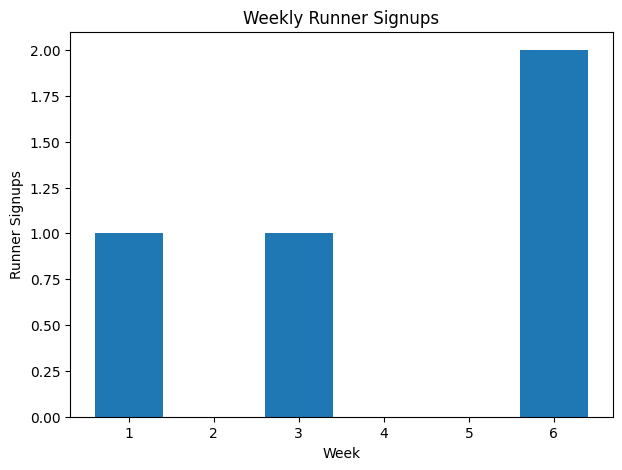

In [37]:
runners['registration_date'].dt.isocalendar().week

weekly_signup = runners.groupby('week')['runner_id'].count().reset_index()

weekly_signup.rename(columns={
    'runner_id':'runner_signup_count'
}, inplace=True)

weekly_signup

import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.bar(
    weekly_signup['week'],
    weekly_signup['runner_signup_count']
)

plt.xlabel('Week')
plt.ylabel('Runner Signups')
plt.title('Weekly Runner Signups')

plt.show()

# **A2.** What is the average time (in minutes) between a runner’s registration date and their first successful pickup?

In [44]:
successful_orders = runner_orders[
    runner_orders['pickup_time'].notna()
]

first_pickup = successful_orders.groupby('runner_id')['pickup_time'].min().reset_index()
runner_time = pd.merge(
    runners,
    first_pickup,
    on='runner_id'
)

runner_time['waiting_time_mins'] = (
    runner_time['pickup_time'] - runner_time['registration_date']
).dt.total_seconds() / 60

runner_time

average_wait = runner_time['waiting_time_mins'].mean()

average_wait

np.float64(20587.5)

# **A3.** What is the total number of successful deliveries completed by each runner?

In [47]:
successful_orders = runner_orders[
    runner_orders['pickup_time'].notna()
]

runner_delivery = successful_orders.groupby('runner_id')['order_id'].count().reset_index()

runner_delivery.rename(columns={
    'order_id':'successful_deliveries'
}, inplace=True)

runner_delivery

,runner_id,successful_deliveries
0,1,3
1,2,2
2,3,1
3,4,1


# **A4.** What is the delivery success rate for each runner? (Successful deliveries ÷ total assigned orders)

In [49]:
total_orders = runner_orders.groupby('runner_id')['order_id'].count().reset_index().rename(
    columns={'order_id':'total_assigned_orders'}
)

successful_delivery = runner_orders[
    runner_orders['pickup_time'].notna()
].groupby('runner_id')['order_id'].count().reset_index().rename(
    columns={'order_id':'successful_deliveries'}
)

runner_success = pd.merge(
    total_orders,
    successful_delivery,
    on='runner_id'
)

runner_success['success_rate'] = (
    runner_success['successful_deliveries']
    /
    runner_success['total_assigned_orders']
) * 100

runner_success

,runner_id,total_assigned_orders,successful_deliveries,success_rate
0,1,3,3,100.0
1,2,2,2,100.0
2,3,2,1,50.0
3,4,1,1,100.0


# **A5.** What is the average delivery speed (km per minute) for each runner? Are there any noticeable performance trends between runners?

In [48]:
successful_orders = runner_orders[
    runner_orders['pickup_time'].notna()
]

successful_orders['speed_km_per_min'] = (
    successful_orders['distance_km']
    /
    successful_orders['duration_mins']
)

runner_speed = successful_orders.groupby('runner_id')['speed_km_per_min'].mean().reset_index()

runner_speed

/tmp/ipykernel_3002/133948962.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  successful_orders['speed_km_per_min'] = (


,runner_id,speed_km_per_min
0,1,0.364798
1,2,0.325000
2,3,0.277778
3,4,0.321429


# **B**. Order & Delivery Insights

**B1.** What is the total number of pizzas ordered?
**B2.** How many unique customer orders were placed?

**B3.** What is the average waiting time (in minutes) from order_time to pickup_time for successful deliveries?

**B4**. What is the difference between the longest and shortest delivery durations for completed deliveries?

**B1**

In [51]:
total_pizzas = customer_orders['pizza_id'].count()

total_pizzas

np.int64(9)

**B2**

In [50]:
unique_orders = customer_orders['order_id'].nunique()

unique_orders

8

**B3**

In [53]:
delivery_time = pd.merge(
    customer_orders,
    runner_orders,
    on='order_id'
)

delivery_time = delivery_time[
    delivery_time['pickup_time'].notna()
]

delivery_time['waiting_time_mins'] = (
    delivery_time['pickup_time']
    -
    delivery_time['order_time']
).dt.total_seconds() / 60

average_wait = delivery_time['waiting_time_mins'].mean()

average_wait

np.float64(10.0)

**B4**

In [54]:
successful_orders = runner_orders[
    runner_orders['duration_mins'] > 0
]

longest_delivery = successful_orders['duration_mins'].max()

shortest_delivery = successful_orders['duration_mins'].min()

delivery_difference = longest_delivery - shortest_delivery

delivery_difference

13.0

# **C**. Ingredient Optimization & Customization
**C1.** What are the standard ingredients used in each pizza? (List ingredient names per pizza)

**C2.** What is the most commonly added extra ingredient?

**C3.** What is the most commonly excluded ingredient?

**C4.** What is the total usage count of each ingredient across all delivered pizzas, sorted from most used to least used?

**C1**

In [55]:
standard_ingredients = pd.merge(
    pd.merge(
        pizza_recipes,
        ingredients,
        on='ingredient_id'
    ),
    pizza_names,
    on='pizza_id'
).groupby('pizza_name')['ingredient_name'].apply(list).reset_index()

standard_ingredients

,pizza_name,ingredient_name
0,Margherita,"[Cheese, Tomato, Basil]"
1,Paneer Tikka,"[Cheese, Paneer, Capsicum]"


**C2**

In [57]:
extras_df = customer_orders[
    customer_orders['extras'] != ''
]

extras_df['extras'] = extras_df['extras'].str.split(',')

extras_df = extras_df.explode('extras')

extras_df['extras'] = extras_df['extras'].astype(int)

extras_df

/tmp/ipykernel_3002/2575222944.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  extras_df['extras'] = extras_df['extras'].str.split(',')


,order_id,customer_id,pizza_id,exclusions,extras,order_time
2,3,203,2,,5,2025-06-21 19:30:00
5,5,205,1,4,5,2025-06-22 21:15:00
6,6,202,2,,6,2025-06-23 17:45:00
8,8,207,2,,1,2025-06-23 19:15:00
8,8,207,2,,6,2025-06-23 19:15:00


In [58]:
extras_df = pd.merge(
    extras_df,
    ingredients,
    left_on='extras',
    right_on='ingredient_id'
)

extras_df

,order_id,customer_id,pizza_id,exclusions,extras,order_time,ingredient_id,ingredient_name
0,3,203,2,,5,2025-06-21 19:30:00,5,Capsicum
1,5,205,1,4,5,2025-06-22 21:15:00,5,Capsicum
2,6,202,2,,6,2025-06-23 17:45:00,6,Olives
3,8,207,2,,1,2025-06-23 19:15:00,1,Cheese
4,8,207,2,,6,2025-06-23 19:15:00,6,Olives


In [59]:
extra_count = extras_df.groupby('ingredient_name')['extras'].count().reset_index().rename(
    columns={'extras':'extra_count'}
)

extra_count = extra_count.sort_values(
    by='extra_count',
    ascending=False
)

extra_count

,ingredient_name,extra_count
0,Capsicum,2
2,Olives,2
1,Cheese,1


**C3**

In [60]:
exclusion_df = customer_orders[
    customer_orders['exclusions'] != ''
]

exclusion_df['exclusions'] = exclusion_df['exclusions'].str.split(',')

exclusion_df = exclusion_df.explode('exclusions')

exclusion_df['exclusions'] = exclusion_df['exclusions'].astype(int)

exclusion_df

/tmp/ipykernel_3002/3650134232.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exclusion_df['exclusions'] = exclusion_df['exclusions'].str.split(',')


,order_id,customer_id,pizza_id,exclusions,extras,order_time
3,3,203,1,4,,2025-06-21 19:30:00
5,5,205,1,4,5,2025-06-22 21:15:00


In [61]:
exclusion_df = pd.merge(
    exclusion_df,
    ingredients,
    left_on='exclusions',
    right_on='ingredient_id'
)

exclusion_df

,order_id,customer_id,pizza_id,exclusions,extras,order_time,ingredient_id,ingredient_name
0,3,203,1,4,,2025-06-21 19:30:00,4,Paneer
1,5,205,1,4,5,2025-06-22 21:15:00,4,Paneer


In [62]:
exclusion_count = exclusion_df.groupby('ingredient_name')['exclusions'].count().reset_index().rename(
    columns={'exclusions':'exclusion_count'}
)

exclusion_count = exclusion_count.sort_values(
    by='exclusion_count',
    ascending=False
)

exclusion_count

,ingredient_name,exclusion_count
0,Paneer,2


**C4**

In [56]:
ingredient_usage_count = pd.merge(
    pd.merge(
        pd.merge(
            customer_orders,
            runner_orders[
                runner_orders['pickup_time'].notna()
            ],
            on='order_id'
        ),
        pizza_recipes,
        on='pizza_id'
    ),
    ingredients,
    on='ingredient_id'
).groupby('ingredient_name')['ingredient_id'].count().reset_index().rename(
    columns={'ingredient_id':'usage_count'}
).sort_values(
    by='usage_count',
    ascending=False
)

ingredient_usage_count

,ingredient_name,usage_count
2,Cheese,8
0,Basil,5
4,Tomato,5
1,Capsicum,3
3,Paneer,3
